安裝套件 & 設定資料範圍

In [2]:
!pip -q install yfinance pandas numpy matplotlib scikit-learn statsmodels pytrends transformers torch
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

START = "2022-01-01"
END   = "2026-01-01"

三、抓資料（至少 2 個來源）

Yahoo Finance（油、金、股市、匯率）

In [19]:
import yfinance as yf
import pandas as pd

symbols = {
    "WTI": "CL=F",
    "GOLD": "GC=F",
    "SP500": "^GSPC",
    "USDJPY": "JPY=X",
}

df = None
for k, s in symbols.items():
    tmp = yf.Ticker(s).history(start=START, end=END)[["Close"]].reset_index()
    tmp = tmp.rename(columns={"Date": "date", "Close": k})
    tmp["date"] = pd.to_datetime(tmp["date"]).dt.tz_localize(None)

    df = tmp if df is None else df.merge(tmp, on="date", how="outer")

df = df.sort_values("date").reset_index(drop=True)

# ✅ 檢查點：一定要是單層欄位
print("df.columns nlevels =", df.columns.nlevels)
print(df.head())

df.columns nlevels = 1
        date        WTI         GOLD        SP500      USDJPY
0 2022-01-03  76.080002  1799.400024  4796.560059  115.141998
1 2022-01-04  76.989998  1814.000000  4793.540039  115.328003
2 2022-01-05  77.849998  1824.599976  4700.580078  116.174004
3 2022-01-06  79.459999  1788.699951  4696.049805  116.127998
4 2022-01-07  78.900002  1797.000000  4677.029785  115.864998


Google Trends（戰爭熱度）

In [20]:
from pytrends.request import TrendReq

pytrends = TrendReq(hl='en-US', tz=0)
kw_list = ["Iran Israel war", "Strait of Hormuz", "oil price"]
pytrends.build_payload(kw_list, timeframe=f"{START} {END}")

tr = pytrends.interest_over_time().reset_index()
tr = tr.rename(columns={"date":"date"})
tr.head()

,date,Iran Israel war,Strait of Hormuz,oil price,isPartial
0,2021-12-26,0,0,21,False
1,2022-01-02,0,0,22,False
2,2022-01-09,0,0,20,False
3,2022-01-16,0,0,21,False
4,2022-01-23,0,0,23,False


四、資料清理與前處理（缺失、轉換、特徵工程）

In [21]:
import numpy as np
import pandas as pd

# 0) Trends 的 date 轉成 datetime，並移除 isPartial
tr["date"] = pd.to_datetime(tr["date"]).dt.tz_localize(None)
if "isPartial" in tr.columns:
    tr = tr.drop(columns=["isPartial"])

# 1) 合併（df 是你用做法2重抓的那個 df）
m = df.merge(tr, on="date", how="left")

# 2) 缺失處理：價格用前值補（交易日差異）
price_cols = ["WTI", "GOLD", "SP500", "USDJPY"]
for c in price_cols:
    if c in m.columns:
        m[c] = m[c].ffill()

# 3) Trends 缺失補 0（非每日/抓不到時）
trend_cols = ["Iran Israel war", "Strait of Hormuz", "oil price"]
for c in trend_cols:
    if c in m.columns:
        m[c] = m[c].fillna(0)

# 4) 特徵工程：log return（常用）
for c in ["WTI", "GOLD", "SP500"]:
    if c in m.columns:
        m[f"{c}_ret"] = np.log(m[c]).diff()

# 5) 清掉因 diff 造成的 NA
m = m.dropna().reset_index(drop=True)

m.head()

,date,WTI,GOLD,SP500,USDJPY,Iran Israel war,Strait of Hormuz,oil price,WTI_ret,GOLD_ret,SP500_ret
0,2022-01-04,76.989998,1814.000000,4793.540039,115.328003,0.0,0.0,0.0,0.011890,0.008081,-0.000630
1,2022-01-05,77.849998,1824.599976,4700.580078,116.174004,0.0,0.0,0.0,0.011108,0.005826,-0.019583
2,2022-01-06,79.459999,1788.699951,4696.049805,116.127998,0.0,0.0,0.0,0.020470,-0.019872,-0.000964
3,2022-01-07,78.900002,1797.000000,4677.029785,115.864998,0.0,0.0,0.0,-0.007072,0.004630,-0.004058
4,2022-01-10,78.230003,1798.400024,4670.290039,115.617996,0.0,0.0,0.0,-0.008528,0.000779,-0.001442


五、時間序列分析（至少 2 張折線圖 + 戰爭前後比較）

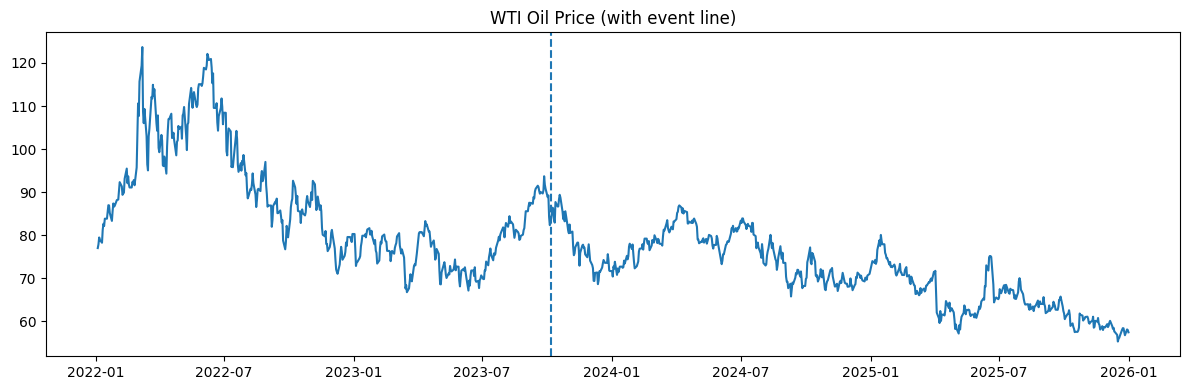

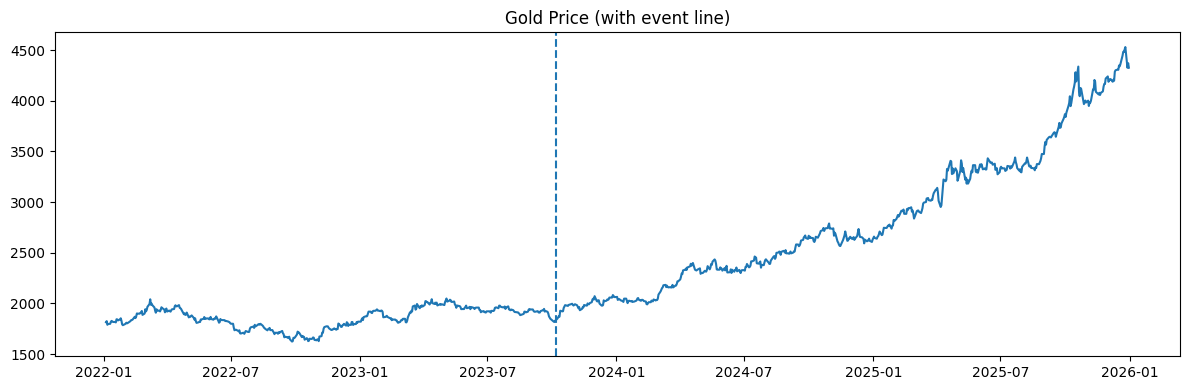

In [22]:
EVENT_DATE = pd.to_datetime("2023-10-07")  # 你可改成你報告要用的事件日

def plot_ts(col, title, fname):
    plt.figure(figsize=(12,4))
    plt.plot(m["date"], m[col])
    plt.axvline(EVENT_DATE, linestyle="--")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(f"output/{fname}", dpi=200)
    plt.show()

import os
os.makedirs("output", exist_ok=True)

plot_ts("WTI", "WTI Oil Price (with event line)", "fig01_wti.png")
plot_ts("GOLD", "Gold Price (with event line)", "fig02_gold.png")

六、相關性分析（Heatmap + 散點圖+回歸線）

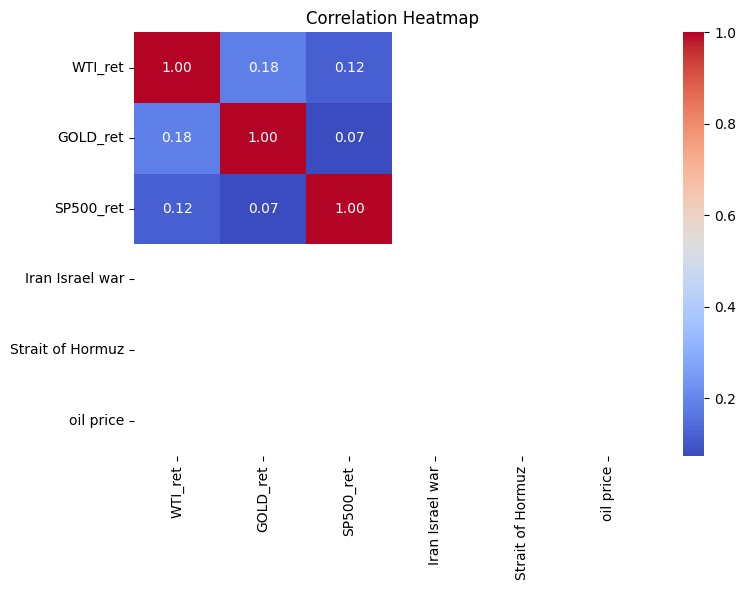

In [23]:
import seaborn as sns

corr_cols = ["WTI_ret","GOLD_ret","SP500_ret"] + trend_cols
corr_cols = [c for c in corr_cols if c in m.columns]
corr = m[corr_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("output/fig03_corr_heatmap.png", dpi=200)
plt.show()

散點 + 回歸線（例：油價報酬 vs 黃金報酬）

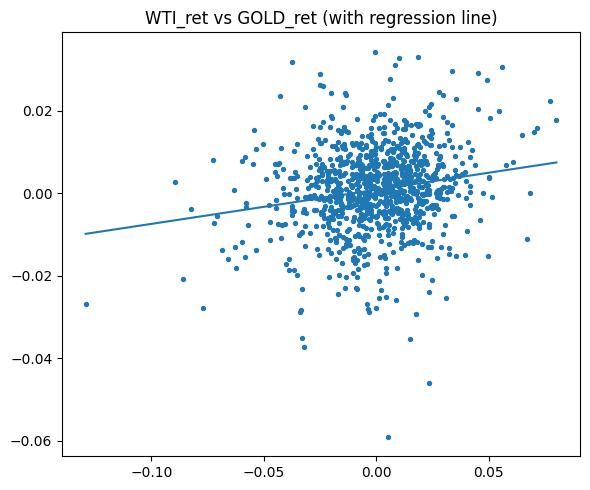

In [24]:
from sklearn.linear_model import LinearRegression

x = m[["WTI_ret"]].values
y = m["GOLD_ret"].values
lr = LinearRegression().fit(x, y)

plt.figure(figsize=(6,5))
plt.scatter(m["WTI_ret"], m["GOLD_ret"], s=8)
xx = np.linspace(m["WTI_ret"].min(), m["WTI_ret"].max(), 100).reshape(-1,1)
plt.plot(xx, lr.predict(xx))
plt.title("WTI_ret vs GOLD_ret (with regression line)")
plt.tight_layout()
plt.savefig("output/fig04_scatter_reg.png", dpi=200)
plt.show()

七、多圖表比較（至少 3 種不同圖表）

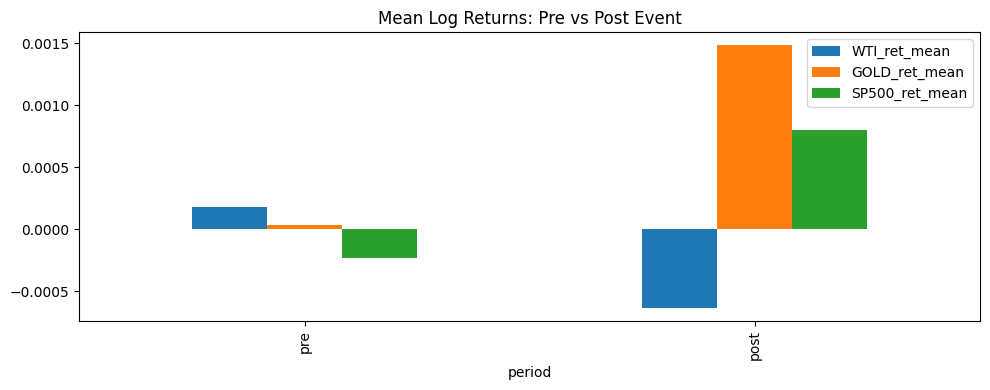

In [25]:
pre = m[m["date"] < EVENT_DATE]
post = m[m["date"] >= EVENT_DATE]

bar_df = pd.DataFrame({
    "period": ["pre","post"],
    "WTI_ret_mean": [pre["WTI_ret"].mean(), post["WTI_ret"].mean()],
    "GOLD_ret_mean": [pre["GOLD_ret"].mean(), post["GOLD_ret"].mean()],
    "SP500_ret_mean": [pre["SP500_ret"].mean(), post["SP500_ret"].mean()],
})

bar_df_plot = bar_df.set_index("period")[["WTI_ret_mean","GOLD_ret_mean","SP500_ret_mean"]]
bar_df_plot.plot(kind="bar", figsize=(10,4))
plt.title("Mean Log Returns: Pre vs Post Event")
plt.tight_layout()
plt.savefig("output/fig05_bar_pre_post.png", dpi=200)
plt.show()

分群分析（Clustering）

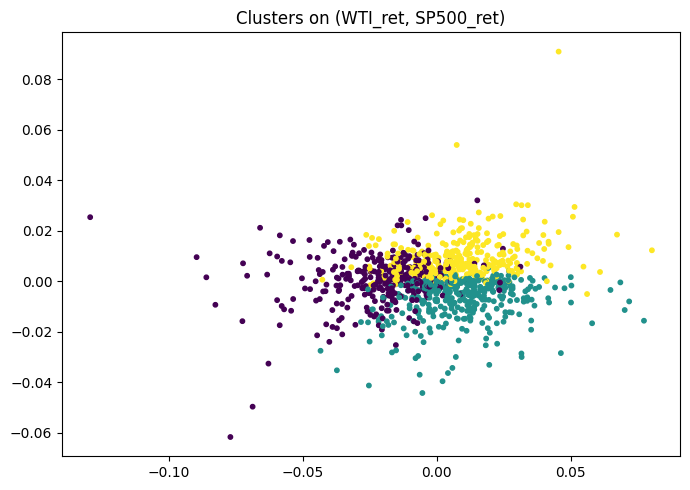

In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

feat = m[["WTI_ret","GOLD_ret","SP500_ret"] + trend_cols].copy()
feat = feat[[c for c in feat.columns if c in m.columns]]

X = StandardScaler().fit_transform(feat.values)
kmeans = KMeans(n_clusters=3, random_state=42, n_init="auto").fit(X)
m["cluster"] = kmeans.labels_

plt.figure(figsize=(7,5))
plt.scatter(m["WTI_ret"], m["SP500_ret"], c=m["cluster"], s=10)
plt.title("Clusters on (WTI_ret, SP500_ret)")
plt.tight_layout()
plt.savefig("output/fig06_cluster.png", dpi=200)
plt.show()

新聞情緒分析(加分)

安裝/載入需要套件

In [28]:
!pip -q install feedparser transformers torch sentencepiece
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 1.2 MB/s eta 0:00:00


抓新聞資料（用 Google News RSS，最穩、最簡）

In [29]:
import feedparser, urllib.parse
from datetime import datetime

def google_news_rss(query: str, days: int = 365, lang="en-US", region="US"):
    q = f'({query}) when:{days}d'
    url = "https://news.google.com/rss/search?" + urllib.parse.urlencode({
        "q": q, "hl": lang, "gl": region, "ceid": f"{region}:{lang.split('-')[0]}"
    })
    feed = feedparser.parse(url)

    rows = []
    for e in feed.entries:
        title = getattr(e, "title", "")
        link = getattr(e, "link", "")
        dt = None
        try:
            dt = datetime(*e.published_parsed[:6]).date() if hasattr(e, "published_parsed") else None
        except Exception:
            dt = None
        rows.append({"date": dt, "title": title, "link": link})

    df_news = pd.DataFrame(rows)
    df_news = df_news.dropna(subset=["date", "title"]).drop_duplicates(subset=["date","title"]).sort_values("date")
    return df_news

# 你可以調整關鍵字（建議保留 war / Iran / Israel / US）
QUERY = "Iran Israel war OR Israel Iran conflict OR US Iran"
df_news = google_news_rss(QUERY, days=365)

print("news count =", len(df_news))
df_news.head()

news count = 100


,date,title,link
39,2025-06-13,Security Council meets in emergency session ov...,https://news.google.com/rss/articles/CBMiV0FVX...
81,2025-06-13,Day One of Israel’s Strikes on Iran: What to K...,https://news.google.com/rss/articles/CBMidkFVX...
34,2025-06-13,Israel’s Strikes on Iran Could Change the Midd...,https://news.google.com/rss/articles/CBMid0FVX...
85,2025-06-13,Why did Israel strike Iran? An Israeli politic...,https://news.google.com/rss/articles/CBMidEFVX...
75,2025-06-13,Israel attacks Iran: What we know so far - Al ...,https://news.google.com/rss/articles/CBMihgFBV...


情緒分析（+1 / 0 / -1）

In [30]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
import torch

MODEL = "cardiffnlp/twitter-xlm-roberta-base-sentiment"

tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

device = 0 if torch.cuda.is_available() else -1
clf = pipeline("text-classification", model=model, tokenizer=tokenizer, device=device)

id2label = model.config.id2label  # {0:'negative',1:'neutral',2:'positive'}

def normalize_label(p_label: str) -> str:
    if p_label.lower().startswith("label_"):
        idx = int(p_label.split("_")[-1])
        return id2label[idx]
    return p_label

def label_to_score(label: str) -> int:
    label = label.lower()
    if "positive" in label: return 1
    if "negative" in label: return -1
    return 0

texts = df_news["title"].fillna("").tolist()

# ✅ 關鍵：避免 token 過長炸掉
preds = clf(texts, batch_size=16, truncation=True, max_length=128)

labels = [normalize_label(p["label"]) for p in preds]
scores = [label_to_score(l) for l in labels]

df_news["sentiment_label"] = labels
df_news["sentiment_score"] = scores

df_news.to_csv("output/news_sentiment.csv", index=False, encoding="utf-8-sig")
df_news[["date","title","sentiment_label","sentiment_score"]].head(10)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-xlm-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,date,title,sentiment_label,sentiment_score
39,2025-06-13,Security Council meets in emergency session ov...,neutral,0
81,2025-06-13,Day One of Israel’s Strikes on Iran: What to K...,neutral,0
34,2025-06-13,Israel’s Strikes on Iran Could Change the Midd...,negative,-1
85,2025-06-13,Why did Israel strike Iran? An Israeli politic...,negative,-1
75,2025-06-13,Israel attacks Iran: What we know so far - Al ...,negative,-1
57,2025-06-14,Israel-Iran strikes: What are the worst-case s...,neutral,0
40,2025-06-14,Israel’s Iran strike provides a historic chanc...,positive,1
88,2025-06-15,Analysis: What options does Iran have in its c...,neutral,0
6,2025-06-16,Israel strikes Iran. What happens next? - Broo...,negative,-1
11,2025-06-16,Twenty questions (and expert answers) on the I...,neutral,0


彙總成「每日情緒指標」並合併回 m

In [31]:
# 1) 每日情緒彙總
daily_sent = df_news.groupby("date").agg(
    news_count=("sentiment_score","size"),
    sent_sum=("sentiment_score","sum"),
    sent_mean=("sentiment_score","mean")
).reset_index()

daily_sent["date"] = pd.to_datetime(daily_sent["date"])

# 2) m 也要確保 date 是 datetime
m["date"] = pd.to_datetime(m["date"])

# 3) merge（沒有新聞的日子補 0）
m2 = m.merge(daily_sent, on="date", how="left")
m2[["news_count","sent_sum","sent_mean"]] = m2[["news_count","sent_sum","sent_mean"]].fillna(0)

# 4) 做隔日報酬（用於「情緒 → 隔日市場」）
for c in ["WTI_ret","GOLD_ret","SP500_ret"]:
    if c in m2.columns:
        m2[c + "_next"] = m2[c].shift(-1)

m2.tail()

,date,WTI,GOLD,SP500,USDJPY,Iran Israel war,Strait of Hormuz,oil price,WTI_ret,GOLD_ret,SP500_ret,cluster,news_count,sent_sum,sent_mean,WTI_ret_next,GOLD_ret_next,SP500_ret_next
1034,2025-12-24,58.349998,4480.600098,6932.049805,156.175995,0.0,0.0,0.0,-0.000514,-0.000491,0.003216,2,0.0,0.0,0.0,-0.027980,0.010766,-0.000304
1035,2025-12-26,56.740002,4529.100098,6929.939941,156.089996,0.0,0.0,0.0,-0.027980,0.010766,-0.000304,0,0.0,0.0,0.0,0.023342,-0.046088,-0.003498
1036,2025-12-29,58.080002,4325.100098,6905.740234,156.462997,0.0,0.0,0.0,0.023342,-0.046088,-0.003498,0,0.0,0.0,0.0,-0.002241,0.010351,-0.001377
1037,2025-12-30,57.950001,4370.100098,6896.240234,156.013000,0.0,0.0,0.0,-0.002241,0.010351,-0.001377,1,0.0,0.0,0.0,-0.009188,-0.010235,-0.007385
1038,2025-12-31,57.419998,4325.600098,6845.500000,156.412994,0.0,0.0,0.0,-0.009188,-0.010235,-0.007385,0,0.0,0.0,0.0,NaN,NaN,NaN


產出 3 張新圖

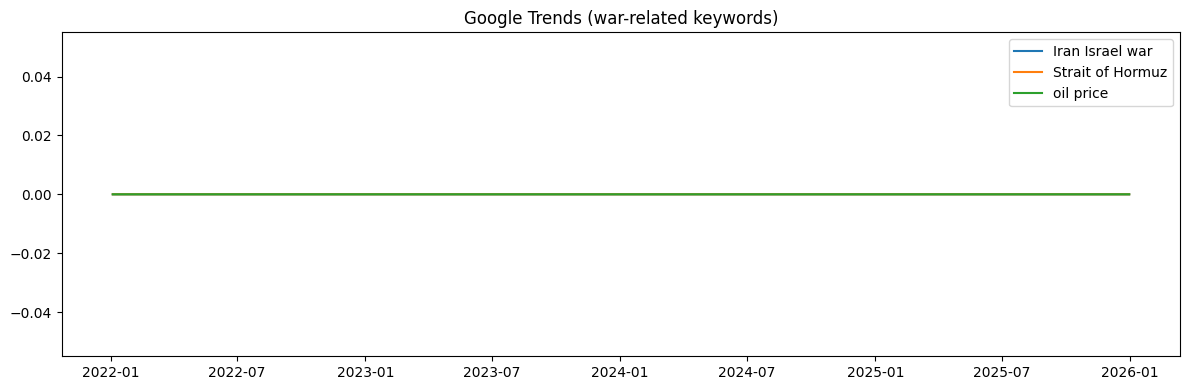

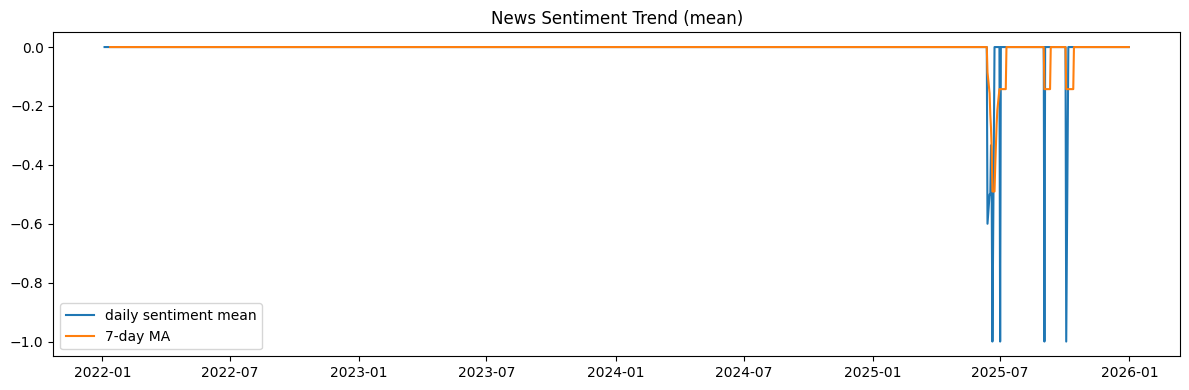

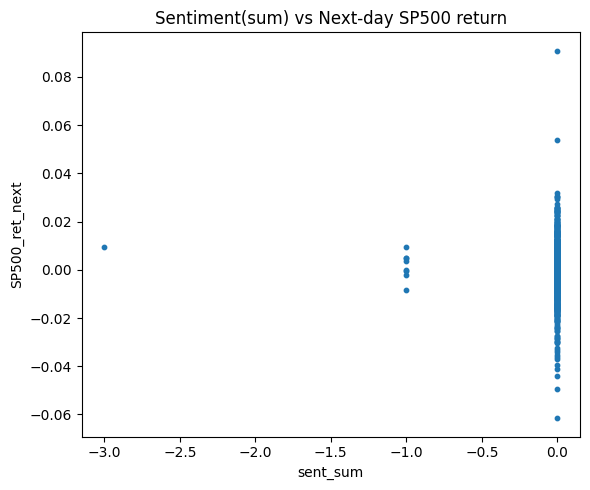

In [32]:
import os
os.makedirs("output", exist_ok=True)

# fig08：Google Trends 三關鍵字折線（補足「多圖表」的視角）
trend_cols = ["Iran Israel war", "Strait of Hormuz", "oil price"]
trend_cols = [c for c in trend_cols if c in m2.columns]

plt.figure(figsize=(12,4))
for c in trend_cols:
    plt.plot(m2["date"], m2[c], label=c)
plt.title("Google Trends (war-related keywords)")
plt.legend()
plt.tight_layout()
plt.savefig("output/fig08_trends.png", dpi=200)
plt.show()

# fig09：新聞情緒趨勢（每日平均 + 7日均線）
plt.figure(figsize=(12,4))
plt.plot(m2["date"], m2["sent_mean"], label="daily sentiment mean")
plt.plot(m2["date"], m2["sent_mean"].rolling(7).mean(), label="7-day MA")
plt.title("News Sentiment Trend (mean)")
plt.legend()
plt.tight_layout()
plt.savefig("output/fig09_news_sentiment_trend.png", dpi=200)
plt.show()

# fig10：情緒 vs 隔日 S&P500 報酬（散點）
plt.figure(figsize=(6,5))
plt.scatter(m2["sent_sum"], m2["SP500_ret_next"], s=10)
plt.title("Sentiment(sum) vs Next-day SP500 return")
plt.xlabel("sent_sum")
plt.ylabel("SP500_ret_next")
plt.tight_layout()
plt.savefig("output/fig10_sentiment_vs_sp500_next.png", dpi=200)
plt.show()

八、AI 預測模型（至少 1 個）+ 預測圖

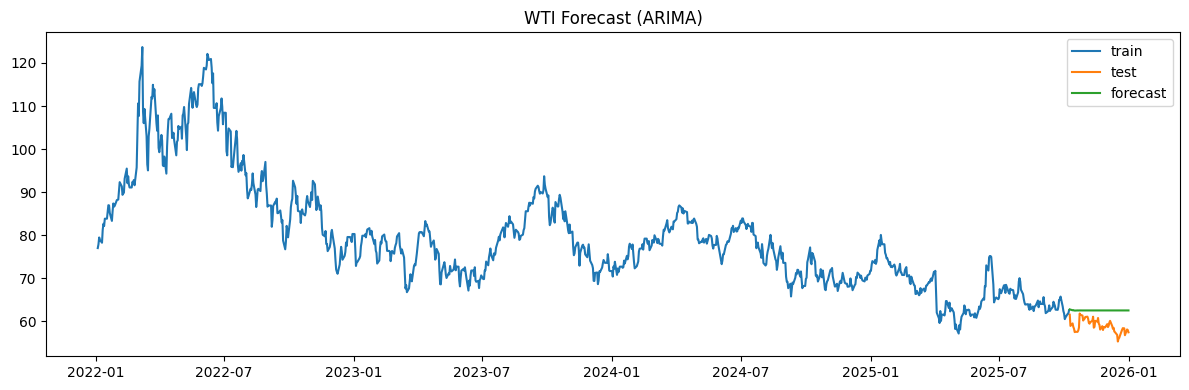

In [27]:
from statsmodels.tsa.arima.model import ARIMA

series = m.set_index("date")["WTI"].asfreq("B").ffill()  # 轉成商業日
train = series.iloc[:-60]
test  = series.iloc[-60:]

model = ARIMA(train, order=(5,1,0)).fit()
fc = model.forecast(steps=60)

plt.figure(figsize=(12,4))
plt.plot(train.index, train, label="train")
plt.plot(test.index, test, label="test")
plt.plot(test.index, fc, label="forecast")
plt.title("WTI Forecast (ARIMA)")
plt.legend()
plt.tight_layout()
plt.savefig("output/fig07_forecast_arima.png", dpi=200)
plt.show()